# Hotel Booking Demand

The report analyses the reservation data of a city hotel and a resort hotel from 2015 to 2017\. The dataset contains over 20k historical hotel booking records with details like hotel type, booking behavior, customer profile, and distribution channel\. The data will be cleaned to remove null values or identify duplicate values before being analysed\. Data will then be visualised with bar charts, histogram to show the trend of lead time, bookings, average daily rate, and cancellations\. After that, explanatory data analysis will be applied with a heat map to identify the relationship between factors and cancellations, as well as pricing\. Lastly, the report will include a diagnostic analysis to provide recommendations for business issues of the hotels\. The report involves Python with some libraries like pandas, numpy, matplotlib, and seaborn for data plotting and manipulation\. 

## 1\. Data importation

The dataset is imported with appropriate libraries to begin the cleaning process\. 

In [1]:
#importing data and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
hotel_bookings = pd.read_csv('hotel_bookings.csv')
print(hotel_bookings)

               hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27   
2                    July     

In [2]:
#showing the head rows of dataset
hotel_bookings.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
#showing the last rows of dataset
hotel_bookings.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


## 2\. Data cleaning

The dataset will be cleaned by removing duplicates and missing values to enable more precise data analysis\.

In [4]:
#Counting duplicate rows in the data frame 
duplicate_rows = hotel_bookings[hotel_bookings.duplicated()]
print("Number of duplicate rows: ", duplicate_rows.shape)

Number of duplicate rows:  (31994, 32)


Although 31,994 rows are identified as duplicates, they will not be removed because the dataset lacks a unique booking identifier\. Identical rows might represent separate bookings with similar information rather than data entry errors\. Removing them could lead to an underestimation of actual booking demand\.

In [5]:
#Identifying missing values in the data frame 
hotel_bookings.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
#Replacing null values with '0' or 'unknown'
hotel_bookings['children']=hotel_bookings['children'].fillna(0)
hotel_bookings['country']=hotel_bookings['country'].fillna('unknown')
hotel_bookings['agent']=hotel_bookings['agent'].fillna(0)
hotel_bookings['company']=hotel_bookings['company'].fillna(0)

In [7]:
#Reviewing the updated data frame
hotel_bookings.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [8]:
#Showing the summary stats for numerical columns in the data frame
hotel_bookings.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,74.828319,10.775157,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,107.141953,53.943884,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [9]:
#Reviewing the updated data frame 
hotel_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## 3\. Descriptive analysis 

Descriptive analysis will be applied to summarise and visualise the trend of reservations and cancellations between the city hotel and resort hotel, providing a holistic view of their performance\.

In [10]:
#Counting the number of reservations that resort hotel and city hotel received
hotel_bookings.hotel.value_counts(ascending=False)

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [11]:
#Counting the number of cancellation by hotel type
hotel_bookings.groupby('hotel')['is_canceled'].value_counts()

hotel         is_canceled
City Hotel    0              46228
              1              33102
Resort Hotel  0              28938
              1              11122
Name: count, dtype: int64

The city hotel recorded 79330 reservations, almost doubling the resort hotel's figure \(40060\)\. However, the number of cancelled reservations at the city hotel was three times that of the resort hotel \(33103 cancellations compared to 11122\)\. Despite that, the city hotel still achieved a significantly greater number of successful bookings, with 46228 reservations compared to 28938 reservations of the resort hotel\.  

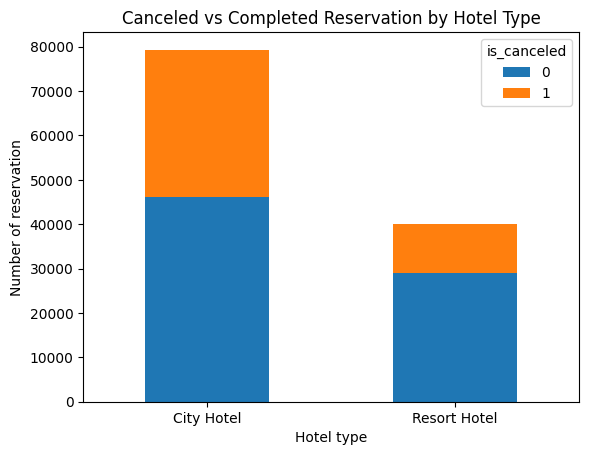

In [13]:
#Comparing the cancelled and completed reservation between city hotel and resort hotel
data = hotel_bookings.groupby(['hotel', 'is_canceled']).size().unstack()
data.plot(kind='bar', stacked=True)
plt.title('Canceled vs Completed Reservation by Hotel Type')
plt.xlabel('Hotel type')
plt.ylabel('Number of reservation')
plt.xticks(rotation=0)
plt.show()

In [38]:
#Calculating the cancellation rate of the city hotel and resort hotel 
hotel_bookings.groupby('hotel')['is_canceled'].value_counts(normalize=True).mul(100).round(2)

hotel         is_canceled
City Hotel    0              58.27
              1              41.73
Resort Hotel  0              72.24
              1              27.76
Name: proportion, dtype: float64

The chart visualises and compares the cancelled and completed bookings for the city hotel and the resort hotel\. As commented above, the city hotel had a much higher total number of bookings, but its cancellation rate doubled the resort hotel's figure \(41\.73% as compared to 27\.76%\)\. The resort hotel showed much fewer overall bookings but a significantly lower rate of cancellations, indicating more stable demand\.

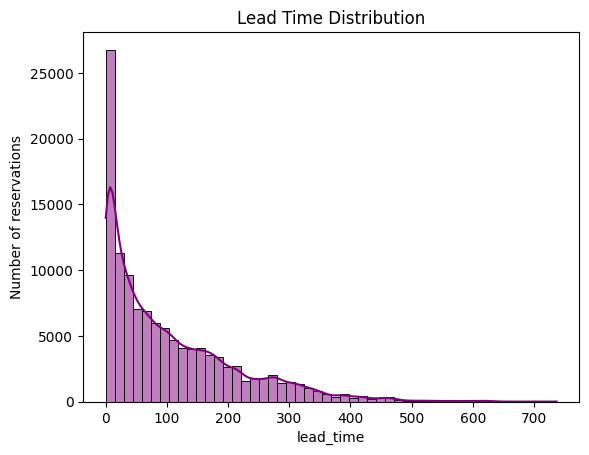

In [14]:
#The distribution of lead time among reservations
sns.histplot(hotel_bookings['lead_time'], bins=50, kde=True,color='purple')
plt.title('Lead Time Distribution')
plt.ylabel('Number of reservations')
plt.show()

The histogram illustrates that most reservations were made in a short time period before the arrival date, with a strong concentration of bookings within the first 50 days\. The frequency then declined rapidly as the lead time increased, forming a long tail that extends beyond 700 days\. This distribution indicates that while early bookings occurred, they were relatively rare compared to last\-minute or short\-term reservations\. The presence of the long tail suggests a small segment of customers who planned their trips far in advance, which might reflect specific travel behaviors such as holiday planning or large group bookings\. Overall, the skewness of the data highlights the importance of managing short\-term demand and suggests that hotels should focus on flexible pricing and cancellation policies to accommodate the high volume of bookings made closer to the check\-in date, while still leveraging early bookings for demand forecasting and revenue optimization\.

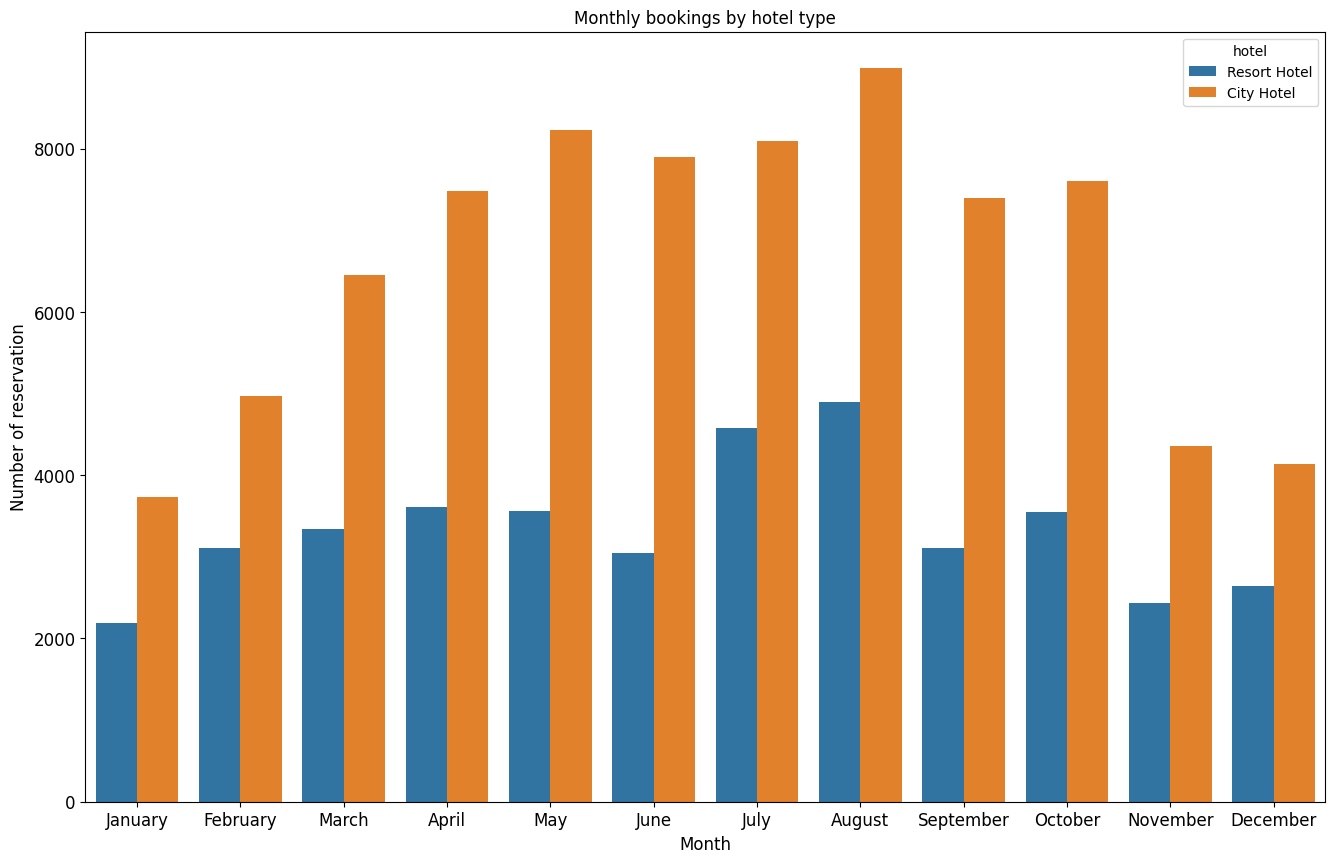

In [15]:
#Comparing the number of reservation by month between resort hotel and city hotel
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
plt.figure(figsize=(16,10))
sns.countplot(x='arrival_date_month', hue='hotel', data=hotel_bookings, order=month_order)
plt.title('Monthly bookings by hotel type')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of reservation', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

The city hotel had a significantly larger number of monthly reservations than the resort hotel over the year, usually doubling the number of reservations of the resort hotel\. The city hotel saw a gradual increase from January to August, from 4000 bookings per month to a peak of about 9000 in August\. After that, the city hotel's monthly bookings dropped dramatically, back to 4000 in December\. By contrast, the monthly reservations of the resort hotel were stable over the year, around 2000 and 3000 bookings per month\. However, the number of reservations of the resort hotel in July and August was nearly twice as many as those of the other months\. Therefore, both hotels could leverage the peak season in the summer months to maximize their revenue\.

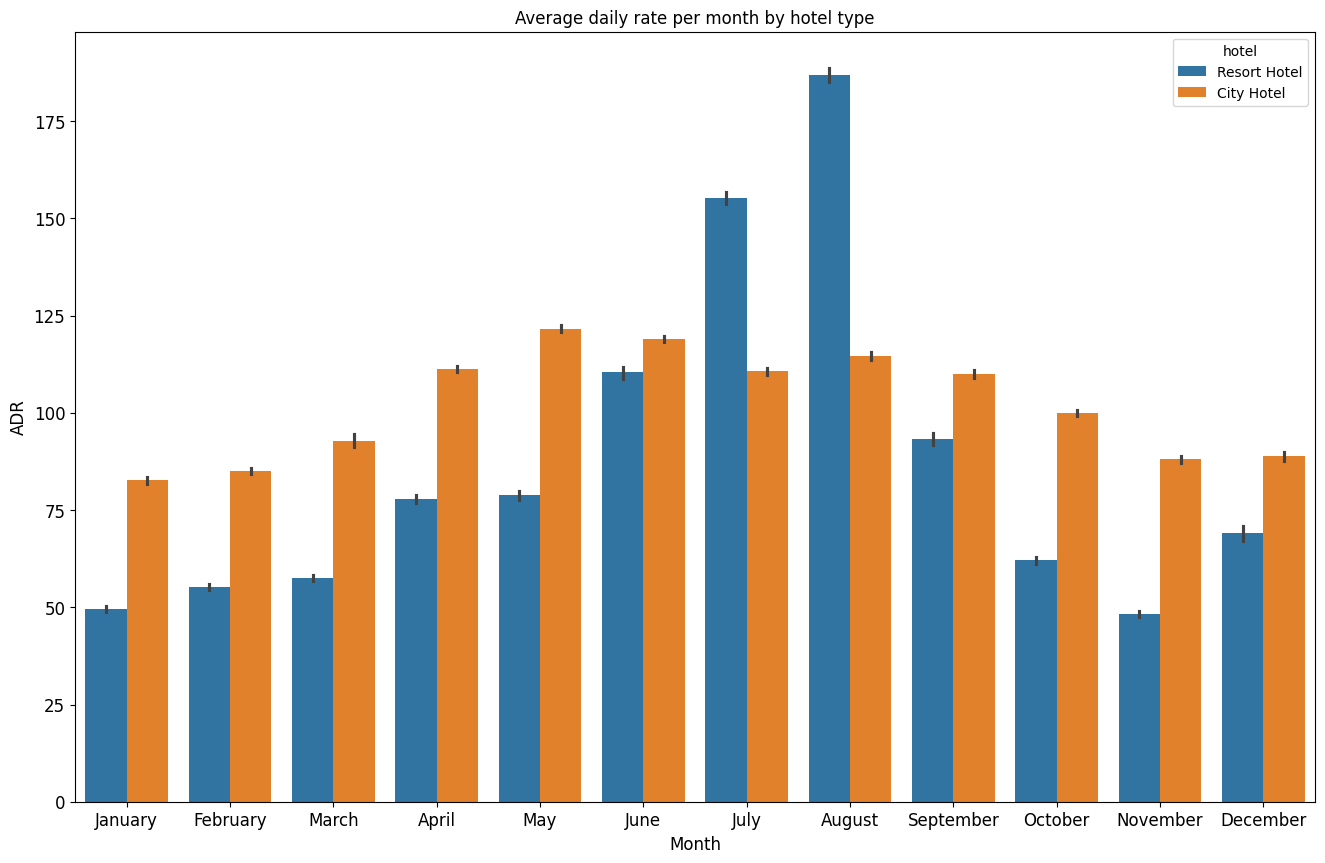

In [17]:
#Comparing ADR per month between resort hotel and city hotel
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
plt.figure(figsize=(16,10))
sns.barplot(x='arrival_date_month', y='adr', hue='hotel', data=hotel_bookings, order=month_order)
plt.title('Average daily rate per month by hotel type')
plt.xlabel('Month', fontsize=12)
plt.ylabel('ADR', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Throughout the year, the city hotel's pricing remained stable \($300\-$400\), showing steady business travel demand\. In contrast, the resort hotel had clear seasonality with a June\-August peak \($600\-$950\), doubling the remaining months\. Besides, the city hotel had a slightly higher ADR than the resort hotel all over the year, except for the summer months\. In August, the resort hotel even had double ADR as compared to the city hotel\. This trend of the resort hotel was understandable, as July and August also witnessed the highest demand for the resort hotel\. The resort hotel must increase the price to optimize its turnover in the peak season\. 

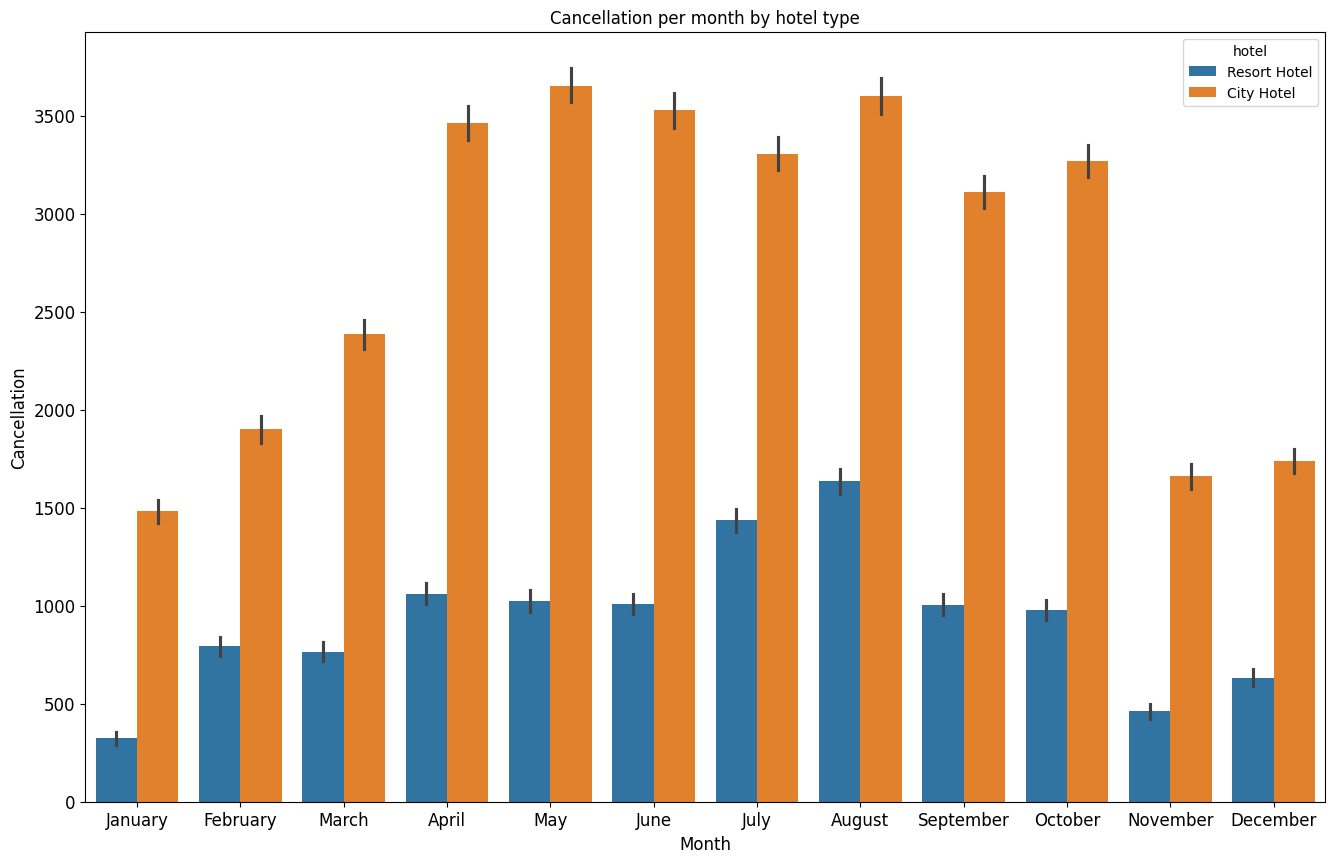

In [18]:
#Counting cancellation per month by hotel type
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
plt.figure(figsize=(16,10))
sns.barplot(x='arrival_date_month', y='is_canceled', hue='hotel', data=hotel_bookings, order=month_order, estimator=np.sum)
plt.title('Cancellation per month by hotel type')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cancellation', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Generally, the city hotel consistently experienced much higher cancellation volumes than the resort hotel throughout the year\. Cancellations for the city hotel showed an upward trend and peaked at 3700 cancellations in the summer \(from April to August\)\. After that, cancellations gradually decreased toward the end of the year, with a noticeable drop in November and December\. In contrast, the resort hotel had much lower cancellation figures and a more moderate pattern\. Cancellations rose steadily from January, reaching their highest point in August at around 1700, before declining again toward the winter months\. The city hotel not only had higher cancellations but also exhibited stronger seasonal fluctuations, particularly during peak travel months\.

# 4\. Exploratory data analysis

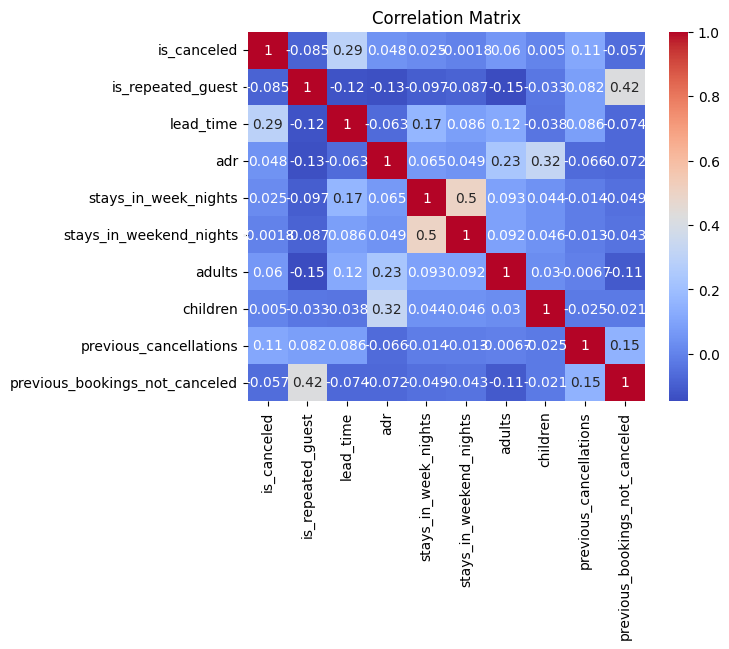

In [33]:
#Creating the correlation heatmap for the selected columns
correlation_matrix = hotel_bookings[[
    'is_canceled', 'is_repeated_guest', 'lead_time', 'adr',
    'stays_in_week_nights', 'stays_in_weekend_nights',
    'adults', 'children',
    'previous_cancellations',
    'previous_bookings_not_canceled'
]].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm') 
plt.title('Correlation Matrix')
plt.show()

The heatmap provides some insightful information on the relationship between factors, especially on cancellation risk and pricing\. Firstly, there was a moderate positive relationship between lead time and cancellations \(0\.29\)\. As discussed above, the reservations made far in advance were more likely to be cancelled\. This means that stricter policies, such as a deposit or cancellation fee, should be applied for early bookings to reduce last\-minute cancellations\. Secondly, the guest with a history of cancellations was more likely to cancel the booking than the guest without a history of cancellations\. However, the correlation coefficients for these relationships are quite small, suggesting weak relationships and the need for further investigation for decision\-making\. Indeed, segmenting customers based on their booking history can help customise strategies, for example, offering incentives to reliable guests and having tighter policies for guests with a history of cancellation\. Thirdly, the guest without a history of cancellations tentatively became a repeat guest, as the correlation coefficient between these relationships is relatively high, at 0\.42\. This figure supports the idea of having special offers for guests with a good history\. Fourthly, ADR showed a positive relationship with bookings with children, but has a weak link to cancellations\. Accordingly, the hotel can have strategies to attract more families with children to improve its revenue\. Besides, pricing was unlikely to affect the cancellation rate\. Lastly, weeknight and weekend stays are strongly connected, showing that hotels have long\-stay reservations\. Nevertheless, neither has a meaningful relationship with cancellations or pricing, meaning that the booking date is not a key driver of cancellation or revenue\. 

# 5\. Diagnostic analysis

## 5\.1\. Did cancelled bookings have longer lead times than completed bookings? 

The descriptive analysis showed that most reservations were made with a short lead time\. Consequently, the diagnostic analysis will review the lead times for cancelled and completed reservations to help the city hotel and resort hotel develop better policies to avoid cancellations in the future\. 

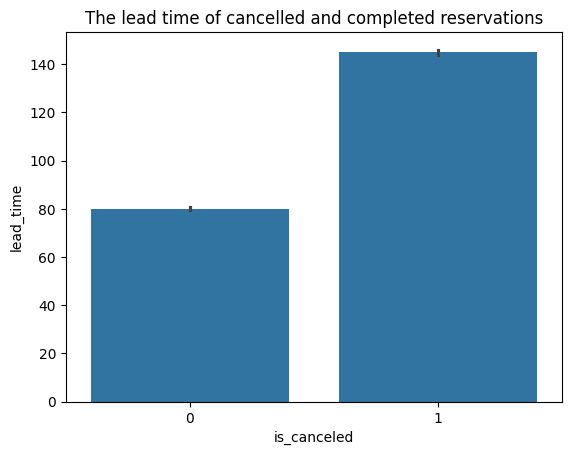

In [19]:
#Comparing the lead time between canceled and completed reservation
sns.barplot(x='is_canceled', y='lead_time', data=hotel_bookings)
plt.title('The lead time of cancelled and completed reservations')
plt.show()

The bar graph shows that the lead time for cancelled reservations nearly doubled that for completed reservations, implying that early bookings were more likely to be cancelled than last\-minute bookings\. More tests should be carried out to verify this claim, so hotels can implement specific policies to manage cancellations and maximise revenue\. 

In [20]:
#t-test to verify if canceled bookings have significantly longer lead time than completed bookings
#H0: The average lead time of canceled and completed bookings is the same 
#H1: Cancelled bookings have longer lead times 
from scipy.stats import ttest_ind
canceled = hotel_bookings[hotel_bookings['is_canceled'] == 1]['lead_time']
completed = hotel_bookings[hotel_bookings['is_canceled'] == 0]['lead_time']
t_stat, p_value = ttest_ind(canceled, completed, equal_var=False)
print("T-statistic:", t_stat) 
print("P-value(two-tailed):", p_value)
p_value_one_tailed = p_value / 2
print("P-value (one-tailed)", p_value_one_tailed)
alpha = 0.05
if (t_stat > 0) and (p_value_one_tailed < alpha):
    print("Reject H0: Canceled bookings have significantly longer lead time.")
else:
    print("Fail to reject H0: No significant evidence that canceled bookings have longer lead time.")

T-statistic: 99.07475331704227
P-value(two-tailed): 0.0
P-value (one-tailed) 0.0
Reject H0: Canceled bookings have significantly longer lead time.


To verify if canceled bookings had much longer lead times than completed bookings, an independent t\-test is conducted\. The result shows a very large positive t\-statistic and a near\-zero p\-value, statistically indicating that canceled bookings had significantly longer lead times than completed bookings at the 5% significance level\. Combining with the bar chart above, this statement becomes more evident\. This suggests that customers who booked far in advance were more likely to cancel due to changes in travel plans\. Consequently, the hotel should have a stricter policy for early bookings to reduce the cancellation rate, as well as better pricing to attract more long\-term reservations and increase occupancy\. By contrast, the hotel can have more flexible cancellation policies for last\-minute bookings, but a higher price to maximise revenue\.

## 5\.2\. Why does the city hotel have a higher cancellation rate than the resort hotel? 

In the descriptive analysis, the city hotel's cancellation rate has been proven to be significantly higher than that of the resort hotel\. Therefore, a diagnostic analysis will be conducted to identify the factors affecting the city hotel's higher cancellation rate\. The analysis investigates three main groups of factors that may influence cancellation behaviors, namely booking behavior, customer profile, and channel factors\. 

### 5\.2\.1 The impact of booking behavior on cancellation rate

Regarding booking behavior, the report will examine lead time and deposit type for reservations, as customers with flexible booking policies and longer planning time might change their travel decisions more easily\. Moreover, it has been proven that cancelled bookings had longer lead times than completed bookings\. 

In [21]:
#Calculating the mean lead time of the city hotel and resort hotel
hotel_bookings.groupby('hotel')['lead_time'].mean()

hotel
City Hotel      109.735724
Resort Hotel     92.675686
Name: lead_time, dtype: float64

Given that cancelled bookings had longer lead times than completed bookings \(as shown in section 4\.1\), the city hotel's longer lead times \(110 days compared to 93 days at the resort hotel\) could be a significant factor behind its higher cancellation rate\. The city hotel's guests tended to book earlier, and the higher cancellation rate might be due to uncertainty in their travel plans\. 

Besides the lead time, the deposit type could be one of the factors influencing the cancellation rate\. For example, the guest could easily cancel the reservation without paying a deposit because they would not be charged\. To verify the relationship between deposit type and cancellation status, a chi\-square test will be performed\. The chi\-square test is applied here, as both deposit and cancellation are categorical variables\.

In [22]:
#Creating a contigency table for a chi-square test
table = pd.crosstab(hotel_bookings['deposit_type'], hotel_bookings['is_canceled'])
table.columns = ['Completed', 'Cancelled']
print(table)

              Completed  Cancelled
deposit_type                      
No Deposit        74947      29694
Non Refund           93      14494
Refundable          126         36


In [23]:
#Performing chi-square test to verify the relationship between deposit type and cancellation
#H0: Deposit type and cancellation status are independent (no relationship)
#H1: Deposit type and cancellation status are dependent
from scipy.stats import chi2_contingency

table = [[74947, 29694],
         [93, 14494],
         [126, 36]]

chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.0


The result \(p < 0\.05\) showed a statistically significant relationship between deposit type and cancellation\. The next step is to calculate the cancellation rate for each deposit type to understand the pattern of the relationship\. 

In [24]:
#Calculate the rate of completed and cancelled bookings among deposit type 
table = pd.crosstab(
    hotel_bookings['deposit_type'],
    hotel_bookings['is_canceled'],
    normalize='index'
) * 100
table.columns = ['Completed', 'Cancelled']
print(table)

              Completed  Cancelled
deposit_type                      
No Deposit    71.622978  28.377022
Non Refund     0.637554  99.362446
Refundable    77.777778  22.222222


According to the table, non\-refundable reservations surprisingly presented the highest cancellation rate, at 99%\. By contrast, the reservations with more flexible cancellation policies showed a high rate of completion\. This observation is contrary to the usual expectation in real business situations, when refundable or no deposit bookings are cancelled more often\. This result might reflect operational or booking system characteristics rather than customer preference alone\.

In [25]:
#Calculating the proportion of deposit types between the city hotel and resort hotel 
pd.crosstab(hotel_bookings['hotel'], hotel_bookings['deposit_type'], normalize='index') * 100

deposit_type,No Deposit,Non Refund,Refundable
hotel,,,
City Hotel,83.753939,16.220850,0.025211
Resort Hotel,95.354468,4.291063,0.354468


The table shows that the city hotel contained a substantially higher percentage of non\-refundable bookings than the resort hotel\. Since non\-refundable reservations represented exceptionally high cancellation rates, the deposit structure might be one of the factors contributing to the higher cancellation rate observed in the city hotel\. 

### 5\.2\.2 The impact of guest profile on the cancellation rate 

About the guest's profile, cancellation history and customer type will be considered for cancellation analysis\.

In [26]:
#Calculating the cancellation frequency of guests 
pd.crosstab(hotel_bookings['hotel'], hotel_bookings['previous_cancellations'], normalize='index') * 100

previous_cancellations,0,1,2,3,4,5,6,11,13,14,19,21,24,25,26
hotel,,,,,,,,,,,,,,,
City Hotel,93.206857,6.498172,0.090760,0.064288,0.031514,0.020169,0.027732,0.04412,0.015127,0.000000,0.000000,0.001261,0.00000,0.000000,0.000000
Resort Hotel,97.266600,2.236645,0.109835,0.034948,0.014978,0.007489,0.000000,0.00000,0.000000,0.034948,0.047429,0.000000,0.11982,0.062406,0.064903


According to the heat map in the exploratory data analysis, guests with a history of cancellations tended to cancel slightly more often than those without\. However, both hotels had relatively similar customer cancellation histories\. Therefore, previous cancellation behavior might minimally contribute to the higher cancellation rates observed in the city hotel\. 

Besides cancellation history, customer type might be one of the factors influencing the cancellation rate\. There were four types of customers, including contract, group, transient, and transient\-party\. As the customer type is a categorical variable, a chi\-square test will be applied to verify if there is any connection between the customer type and cancellation\. 

In [27]:
#Calculating the cancellation rate of different customer types 
table = pd.crosstab(hotel_bookings['customer_type'], hotel_bookings['is_canceled'], normalize='index') * 100
table.columns = ['Completed', 'Cancelled']
print(table)

                 Completed  Cancelled
customer_type                        
Contract         69.038273  30.961727
Group            89.774697  10.225303
Transient        59.253680  40.746320
Transient-Party  74.570132  25.429868


In [28]:
#Chi-square test to verify the relation between customer types and cancellation 
#H0: Customer type and cancellation status are independent (no relationship)
#H1: Customer type and cancellation status are dependent
from scipy.stats import chi2_contingency

table = pd.crosstab(hotel_bookings['customer_type'], hotel_bookings['is_canceled'])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.0


The chi\-square test result is 0\.00, indicating that customer type and cancellation were significantly associated\. Then, the percentage of customer types across the city hotel and resort hotel will be calculated to examine whether the share of customer types had an impact on the high cancellation rate of the city hotel\. 

In [29]:
#Calculating the percentage of customer types between the city hotel and resort hotel
pd.crosstab(hotel_bookings['hotel'], hotel_bookings['customer_type'], normalize='index') * 100

customer_type,Contract,Group,Transient,Transient-Party
hotel,,,,
City Hotel,2.899281,0.369343,74.882138,21.849237
Resort Hotel,4.433350,0.708937,75.409386,19.448328


Although customer type was significantly associated with booking cancellation, the share of customer types between the city and resort hotels was relatively similar\. While transient and contract guests had the highest rate of cancellation, there was no significant difference in the proportion of these guests between the city and resort hotels\. Consequently, the customer profile was unlikely to be a major factor explaining the higher cancellation rates observed in city hotels\.

### 5\.2\.3 The impact of distribution channel on the cancellation rate

Moving to the distribution channel, the chi\-square test is also applied here, as the channel is categorical information\. The reservations of both hotels were distributed through different channels, from online to offline, from direct bookings to corporate\. The cancellation rate of different market segments and the share of market segments across hotels will be calculated to verify if the distribution channel can explain the cancellation rate observed in the city hotel and resort hotel\. 

In [30]:
#Calculating the cancellation rate of different market segments
table = pd.crosstab(hotel_bookings['market_segment'], hotel_bookings['is_canceled'], normalize='index') * 100
table.columns = ['Completed', 'Cancelled']
print(table)

                Completed   Cancelled
market_segment                       
Aviation        78.059072   21.940928
Complementary   86.944818   13.055182
Corporate       81.265345   18.734655
Direct          84.658099   15.341901
Groups          38.937964   61.062036
Offline TA/TO   65.683967   34.316033
Online TA       63.278857   36.721143
Undefined        0.000000  100.000000


In [31]:
#Chi-square test to verify the relationship between market segment and cancellation
#H0: Customer type and cancellation status are independent (no relationship)
#H1: Customer type and cancellation status are dependent
from scipy.stats import chi2_contingency

table = pd.crosstab(hotel_bookings['market_segment'], hotel_bookings['is_canceled'])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.0


In [32]:
#Calculating the share of market segment between city hotel and resort hotel
pd.crosstab(hotel_bookings['hotel'], hotel_bookings['market_segment'], normalize='index') * 100

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
hotel,,,,,,,,
City Hotel,0.298752,0.683222,3.764024,7.680575,17.616286,21.110551,48.844069,0.002521
Resort Hotel,0.000000,0.501747,5.763854,16.258113,14.568148,18.652022,44.256116,0.000000


Based on the chi\-square test result \(0\.0\), the market segment and cancellation were strongly related\. In two hotels, the city hotel showed greater dependence on bookings from online and offline TA, as well as group reservations, which presented the highest cancellation rates among distribution channels\. In contrast, the resort hotel had a substantially higher proportion of direct bookings, which was associated with a lower cancellation rate\. This means that booking channel percentages could partially explain the higher cancellation rate observed in the city hotel\. 

### Conclusion on the reason for the higher cancellation rate of the city hotel and recommendations 

To conclude, there were some factors that probably explained the higher cancellation rate of the city hotel compared to the resort hotel\. First and foremost, booking behaviors, including lead time and deposit type, were likely to play an important role\. As the analysis showed that cancelled bookings had longer lead times than completed bookings, the city hotel's average lead time, approximately 20 days longer than that of the resort hotel, could have negatively contributed to its higher cancellation rate\. Besides, non\-refundable bookings showed the highest cancellation rate, and the city hotel had a relatively larger share of this type of booking than the resort hotel\. Secondly, the distribution channel might also have influenced cancellation behaviour\. Indeed, the city hotel had a moderately higher proportion of bookings from groups, online, and offline TA, which were the distribution channels with the highest cancellation rate\. 

Regarding the lead time, the city hotel should adopt strategies to encourage shorter booking lead times\. The city hotel can offer promotional rates for last\-minute bookings and introduce special discounts as the arrival date approaches\. Additionally, the hotel should send reminders and confirmation emails to guests with long lead times to reduce the likelihood of cancellation\. For the cancellation policy, the city hotel should review its deposit and payment policies\. Since certain deposit types had higher cancellation rates, management could try more effective cancellation policies, such as partial deposits or flexible cancellation policies\. This could encourage stronger booking commitment while maintaining customer satisfaction\. Moving to the distribution channel, the city hotel should diversify its booking profile, pushing incentives to promote booking channels with lower cancellation rates\. The city hotel can create complementary programs to attract more direct or complementary reservations, which have the highest rate of completed bookings\. Besides, to tackle the high cancellation rate of groups, online and offline TA, the hotel should strengthen its booking management for these segments\. For example, the hotel could keep reminding guests about the booking and asking for earlier confirmation, collaborate with travel agencies to improve booking accuracy, and provide benefits for customers who maintain their reservations until check\-in\. In addition, the hotel could develop a predictive analytics system to identify reservations with a high probability of cancellation\. Factors such as lead time, booking channel, customer type, and deposit type could be included in the model\. By identifying high\-risk bookings in advance, the city hotel can take proactive measures to minimise the negative impact of cancellation on occupancy and revenue\. 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0f377fec-6e8a-4cf5-b421-69ff5f2d5bdd' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>